# Détection fraude bancaire

HDFS : localhost:9000
PaySim (transactions mobile money synthétiques & anonymisées
Random Forest

`start-dfs.sh` et `start-yarn.sh`
hdfs://localhost:9000/data/raw/fraud.csv

---

## Problematique : peut-on faire mieux que la banque ?

La banque possède un système anti-fraude (`isFlaggedFraud`)
=> est-il efficace, et peut-on faire mieux ?

## Réglage

In [1]:
MODE_TEST = False   # True = petite partie du csv pour test 
TAILLE_ECHANTILLON = 0.05   # 5%

## Démarrage de Spark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("DetectionFraude") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

print(spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/22 01:35:55 WARN Utils: Your hostname, PortabledeNey, resolves to a loopback address: 127.0.1.1; using 172.29.180.170 instead (on interface eth0)
26/07/22 01:35:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/22 01:35:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


4.1.2


## 1. Importation dataset depuis HDFS

In [3]:
CHEMIN_HDFS = "hdfs://localhost:9000/data/raw/fraud.csv"

df = spark.read.csv(CHEMIN_HDFS, header=True, inferSchema=True)

if MODE_TEST:
    df = df.sample(fraction=TAILLE_ECHANTILLON, seed=67)
    print(f" {TAILLE_ECHANTILLON*100:.0f}% des donnees")
else:
    print("tout")

[Stage 1:===>                                                     (1 + 15) / 16]

tout


## 2. Parsing

In [4]:
df.show(5)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

In [5]:
print("colonnes & types :")
df.printSchema()

colonnes & types :
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)



In [6]:
#nb lignes 
print(df.count())

[Stage 3:>                                                        (0 + 16) / 16]

6362620


---
# 1 systeme de la banque ?

La colonne `isFlaggedFraud` est le système d'alerte de la banque.
Sa règle : lever une alerte si un transfert dépasse 200 000

 on test: On croise ce qu'il a signalé (`isFlaggedFraud`)
avec la vraie fraude (`isFraud`).

In [7]:
df.groupBy("isFraud", "isFlaggedFraud").count().orderBy("isFraud", "isFlaggedFraud").show()

[Stage 6:=======================================>                 (11 + 5) / 16]

+-------+--------------+-------+
|isFraud|isFlaggedFraud|  count|
+-------+--------------+-------+
|      0|             0|6354407|
|      1|             0|   8197|
|      1|             1|     16|
+-------+--------------+-------+



In [8]:
# on compte les fraudes detectees et ratees par le systeme de la banque
fraudes_oui = df.filter((df.isFraud == 1) & (df.isFlaggedFraud == 1)).count()
fraudes_non = df.filter((df.isFraud == 1) & (df.isFlaggedFraud == 0)).count()
totalF = fraudes_oui + fraudes_non

print("f detectees banque :", fraudes_oui)
print("f ratees banque    :", fraudes_non)
print("total f            :", totalF)
print("taux de detection  :", round(100 * fraudes_oui / totalF, 2), "%")

[Stage 12:>                                                       (0 + 16) / 16]

f detectees banque : 16
f ratees banque    : 8197
total f            : 8213
taux de detection  : 0.19 %


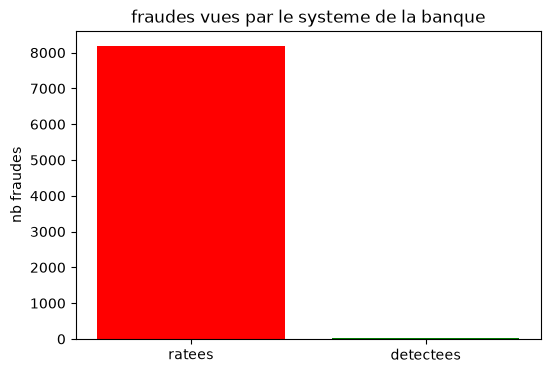

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(["ratees", "detectees"], [fraudes_non, fraudes_oui], color=["red", "green"])
plt.title("fraudes vues par le systeme de la banque")
plt.ylabel("nb fraudes")
plt.show()

### Conclusion 

Le système de la banque ne détecte quasiment rien


C'est notre point de départ et notre référence à battre
On peut donc supprimer cette colonne : elle n'apporte aucune information utile.

---
# 2 sur quels colonnes peut-on se baser 

### combien de fraudes? 

In [10]:
repartition = df.groupBy("isFraud").count()
repartition.show()

[Stage 15:===>                                                    (1 + 15) / 16]

+-------+-------+
|isFraud|  count|
+-------+-------+
|      1|   8213|
|      0|6354407|
+-------+-------+



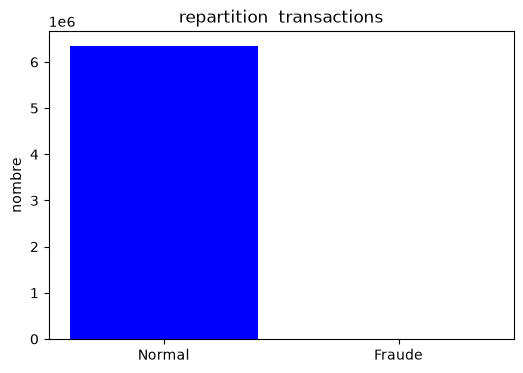

pourcentage de fraude : 0.129 %


In [11]:
nb_fraude = df.filter(df.isFraud == 1).count()
nb_normal = df.filter(df.isFraud == 0).count()

plt.figure(figsize=(6, 4))
plt.bar(["Normal", "Fraude"], [nb_normal, nb_fraude], color=["blue", "red"])
plt.title("repartition  transactions")
plt.ylabel("nombre")
plt.show()

print("pourcentage de fraude :", round(100 * nb_fraude / (nb_fraude + nb_normal), 3), "%")


=>Le dataset est très déséquilibré

### Type de transaction 

In [12]:
print("fraude /type de transaction :")
df.groupBy("type", "isFraud").count().orderBy("type").show()

fraude /type de transaction :


[Stage 24:==============>                                         (4 + 12) / 16]

+--------+-------+-------+
|    type|isFraud|  count|
+--------+-------+-------+
| CASH_IN|      0|1399284|
|CASH_OUT|      0|2233384|
|CASH_OUT|      1|   4116|
|   DEBIT|      0|  41432|
| PAYMENT|      0|2151495|
|TRANSFER|      1|   4097|
|TRANSFER|      0| 528812|
+--------+-------+-------+



+--------+-----+
|    type|count|
+--------+-----+
|TRANSFER| 4097|
|CASH_OUT| 4116|
+--------+-----+



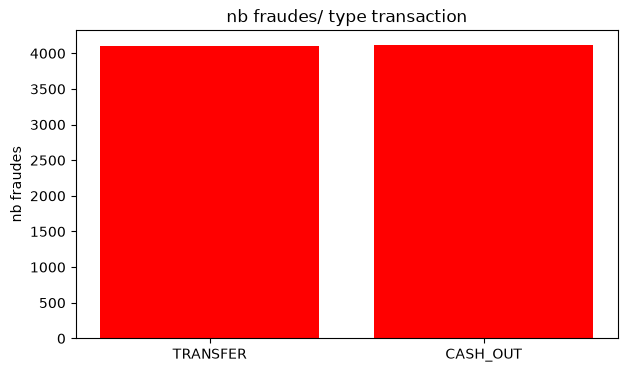

In [13]:
# on veut fraudes / types 
fraudes_par_type = df.filter(df.isFraud == 1).groupBy("type").count()
fraudes_par_type.show()

# panda pour resultats petits 
data = fraudes_par_type.toPandas()

plt.figure(figsize=(7, 4))
plt.bar(data["type"], data["count"], color="red")
plt.title("nb fraudes/ type transaction")
plt.ylabel("nb fraudes")
plt.show()

=>que sur TRANSFER et CASH_OUT
Jamais sur PAYMENT, DEBIT, CASH_IN
=> fraudeur transfère l'argent volé puis le retire

### Entre qui? (particulier/commerçant)

 id de comptes commencent  par
**C** = client / particulier
**M** = merchant / commerce

on veut de qui à qui : (CC ouCM...) et on s'en fiche des chiffres apres 

In [14]:
df = df.withColumn(
    "typeEchange",
    F.concat(F.substring("nameOrig", 1, 1), F.substring("nameDest", 1, 1))
)

print("fraude / type d'echange (CC, CM...) :")
df.groupBy("typeEchange", "isFraud").count().orderBy("typeEchange").show()

fraude / type d'echange (CC, CM...) :


[Stage 33:>                                                       (0 + 16) / 16]

+-----------+-------+-------+
|typeEchange|isFraud|  count|
+-----------+-------+-------+
|         CC|      0|4202912|
|         CC|      1|   8213|
|         CM|      0|2151495|
+-----------+-------+-------+



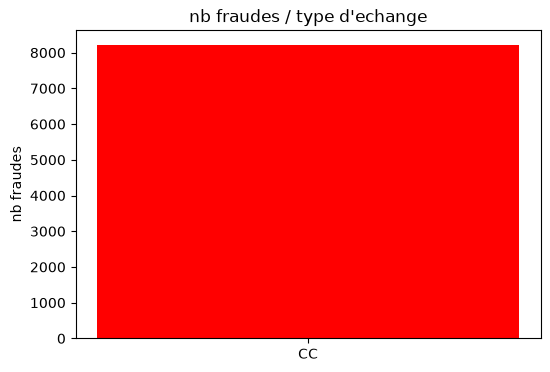

In [15]:
fraudes_par_echange = df.filter(df.isFraud == 1).groupBy("typeEchange").count()
data = fraudes_par_echange.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(data["typeEchange"], data["count"], color="red")
plt.title("nb fraudes / type d'echange")
plt.ylabel("nb fraudes")
plt.show()

=> fraudes sont de type CC
Aucune fraude vers un commerçant.

### Les montants 

In [16]:
df.select("amount").describe().show()

[Stage 39:>                                                       (0 + 16) / 16]

+-------+------------------+
|summary|            amount|
+-------+------------------+
|  count|           6362620|
|   mean|179861.90354913156|
| stddev| 603858.2314629381|
|    min|               0.0|
|    max|     9.244551664E7|
+-------+------------------+



[Stage 45:>                                                       (0 + 16) / 16]

montant moy fraude     : 1467967.3
montant moy non fraude : 178197.04


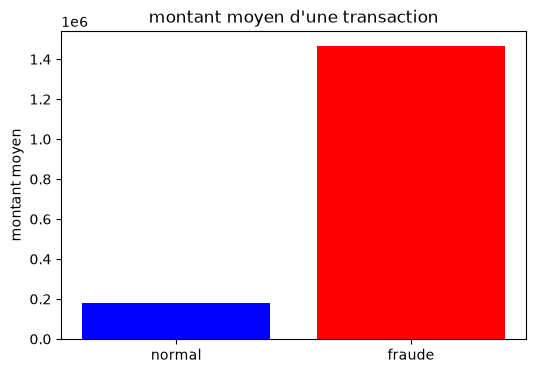

In [17]:
# montant moy. fraudes / non fraudes
moy_fraude = df.filter(df.isFraud == 1).agg(F.avg("amount")).collect()[0][0]
moy_non_fraude = df.filter(df.isFraud == 0).agg(F.avg("amount")).collect()[0][0]

print("montant moy fraude     :", round(moy_fraude, 2))
print("montant moy non fraude :", round(moy_non_fraude, 2))

plt.figure(figsize=(6, 4))
plt.bar(["normal", "fraude"], [moy_non_fraude, moy_fraude], color=["blue", "red"])
plt.title("montant moyen d'une transaction")
plt.ylabel("montant moyen")
plt.show()

=> fraudes portent en moyenne sur des montants plus élevés


### Bilan :



1  dataset déséquilibré 
2  uniquement sur TRANSFER et CASH_OUT 
3  uniquement entre particuliers (CC) 
4  Montants plus élevés 

---
## Nettoyage 

In [18]:
# doublons
df = df.dropDuplicates()

In [19]:
# on vire :
#  id de compte (nameOrig / nameDest) 
#  isFlaggedFraud : l'ancien systeme banque
df = df.select(
    "step", "type", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "typeEchange", "isFraud"
)

In [20]:
# si col isFraud vite on vire 
df = df.dropna(subset=["isFraud"])

---
# 3 : Premier RF


MLlib a besoin de variables numériques rassemblées dans une colonne(features) :
- StringIndexer : texte ("PAYMENT", "CC"...) = nombres
- vectorAssembler: rassemble les colonnes = 1 vecteur
- RandomForestClassifier: le modèle (des arbres qui votent)

In [21]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [22]:
# colonnes txt -> nb
indexeur_type = StringIndexer(inputCol="type", outputCol="type_num")
indexeur_echange = StringIndexer(inputCol="typeEchange", outputCol="typeEchange_num")

In [23]:
#  colonnes pour predire 
col_avec_soldes = [
    "step", "type_num", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "typeEchange_num"
]
assembleur_1 = VectorAssembler(inputCols=col_avec_soldes, outputCol="features")

In [24]:
# 50 ab decision
modele_rf_1 = RandomForestClassifier(
    featuresCol="features",
    labelCol="isFraud",
    numTrees=50
)

pipeline_1 = Pipeline(stages=[indexeur_type, indexeur_echange, assembleur_1, modele_rf_1])

In [25]:
# sep 80/20
train, test = df.randomSplit([0.8, 0.2], seed=67)

In [26]:
modele_1 = pipeline_1.fit(train)

[Stage 99:========================================================(16 + 0) / 16]

In [27]:
predictions_1 = modele_1.transform(test)
print("ex pred")
predictions_1.select("isFraud", "prediction", "probability").show(10)

ex pred


[Stage 102:>                                                        (0 + 1) / 1]

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.99966551365588...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99956181996026...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99963063903278...|
|      0|       0.0|[0.99934638641525...|
|      0|       0.0|[0.99934638641525...|
+-------+----------+--------------------+
only showing top 10 rows


### Éval modele 1

In [28]:
def evaluer(predictions, nom):
    # rappel pour le auc 1.0 = (trop) parfait, 0.5 = hasard
    evaluateur = BinaryClassificationEvaluator(
        labelCol="isFraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    auc = evaluateur.evaluate(predictions)

    # les cas de la matrice de confusion
    vp = predictions.filter((predictions.isFraud == 1) & (predictions.prediction == 1)).count()  # vrais positifs
    fn = predictions.filter((predictions.isFraud == 1) & (predictions.prediction == 0)).count()  # faux negatifs
    fp = predictions.filter((predictions.isFraud == 0) & (predictions.prediction == 1)).count()  # faux positifs

    # recall = parmi les vraies fraudes, combien on en attrape
    recall = vp / (vp + fn)

    print(nom)
    print("AUC       :", round(auc, 4))
    print("detectees :", vp)
    print("ratees    :", fn)
    print("erreurs   :", fp)
    print("recall    :", round(100 * recall, 1), "%")

    return auc, recall, vp, fn, fp

In [29]:
auc_1, recall_1, vp_1, fn_1, fp_1 = evaluer(predictions_1, "modele 1 (avec soldes)")

[Stage 133:===================================================>   (16 + 1) / 17]

modele 1 (avec soldes)
AUC       : 0.9878
detectees : 727
ratees    : 952
erreurs   : 1
recall    : 43.3 %


In [30]:
# MC
predictions_1.groupBy("isFraud", "prediction").count().orderBy("isFraud", "prediction").show()

[Stage 139:===================================================>   (16 + 1) / 17]

+-------+----------+-------+
|isFraud|prediction|  count|
+-------+----------+-------+
|      0|       0.0|1271431|
|      0|       1.0|      1|
|      1|       0.0|    952|
|      1|       1.0|    727|
+-------+----------+-------+



### sur quelles colonnes le modele se base?

In [31]:
rf_1 = modele_1.stages[-1]
imp_1 = rf_1.featureImportances

for nom, score in zip(col_avec_soldes, imp_1):
    print(nom, ":", round(float(score), 4))

step : 0.0481
type_num : 0.1212
amount : 0.0761
oldbalanceOrg : 0.3535
newbalanceOrig : 0.0575
oldbalanceDest : 0.0661
newbalanceDest : 0.2754
typeEchange_num : 0.0022


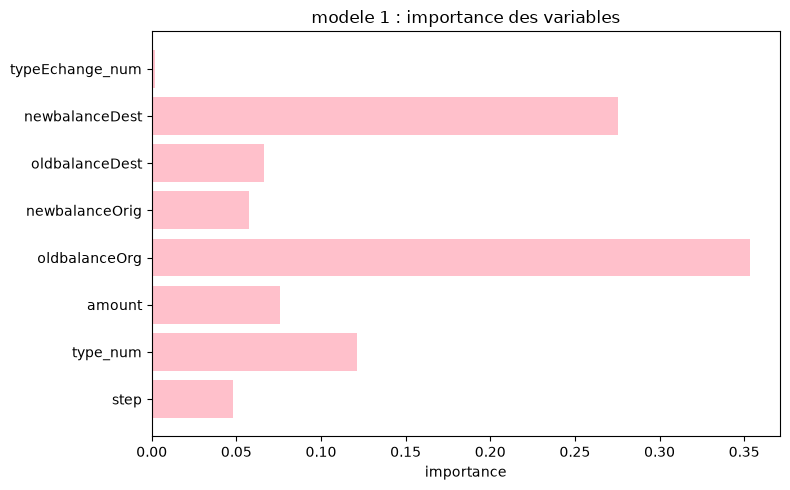

In [32]:
# graph importances
noms = []
vals = []
for i in range(len(col_avec_soldes)):
    noms.append(col_avec_soldes[i])
    vals.append(float(imp_1[i]))

plt.figure(figsize=(8, 5))
plt.barh(noms, vals, color="pink")
plt.title("modele 1 : importance des variables")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

---
## Probleme : le modele triche

AUC 0.98 = trop elever alors que loupe bcp de fraudes

doc du dataset :
> *« NOTE: Transactions which are detected as fraud are cancelled, so for fraud
> detection these columns (oldbalanceOrg, newbalanceOrig, oldbalanceDest,
> newbalanceDest) must not be used. »*

=> les fraudes sont annulees donc les soldes sont modifies APRES coup
=> ces 4 colonnes ne doivent pas etre utilisees
 le modele se base trop sur oldbalanceOrg + newbalanceDest

### fuite de donnees 

le modele apprend une consequence de la fraude, pas la fraude

=> on refait sans ces colonnes

---
# 4 : RF sans les soldes

meme chose mais sans les 4 colonnes de soldes
=> le modele a que ce qu'on sait AU MOMENT de la transaction

In [33]:
#  colonnes pour predire (sans soldes)
col_sans_soldes = ["step", "type_num", "amount", "typeEchange_num"]
assembleur_2 = VectorAssembler(inputCols=col_sans_soldes, outputCol="features")

In [34]:
modele_rf_2 = RandomForestClassifier(
    featuresCol="features",
    labelCol="isFraud",
    numTrees=50
)

pipeline_2 = Pipeline(stages=[indexeur_type, indexeur_echange, assembleur_2, modele_rf_2])

In [35]:
# meme train/test que modele 1 pour comparer
modele_2 = pipeline_2.fit(train)
predictions_2 = modele_2.transform(test)

[Stage 194:============================================>          (13 + 3) / 16]

In [36]:
auc_2, recall_2, vp_2, fn_2, fp_2 = evaluer(predictions_2, "modele 2 (sans soldes)")

[Stage 225:===================================================>   (16 + 1) / 17]

modele 2 (sans soldes)
AUC       : 0.8723
detectees : 0
ratees    : 1679
erreurs   : 0
recall    : 0.0 %


In [37]:
# matrice de confusion
predictions_2.groupBy("isFraud", "prediction").count().orderBy("isFraud", "prediction").show()

[Stage 231:===================================================>   (16 + 1) / 17]

+-------+----------+-------+
|isFraud|prediction|  count|
+-------+----------+-------+
|      0|       0.0|1271432|
|      1|       0.0|   1679|
+-------+----------+-------+



step : 0.1786
type_num : 0.5304
amount : 0.2893
typeEchange_num : 0.0017


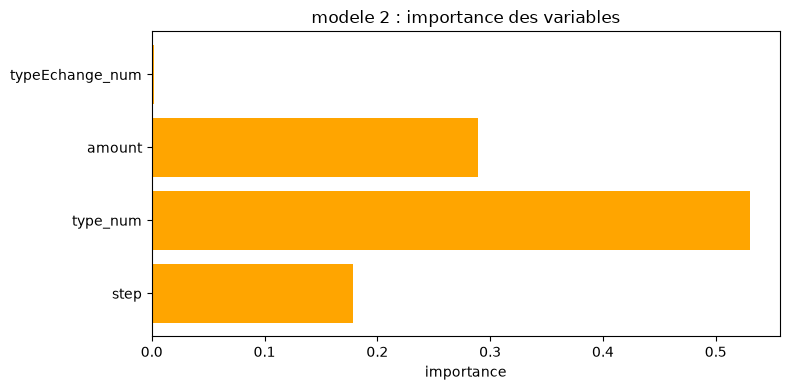

In [38]:
# sur quoi le modele 2 se base
rf_2 = modele_2.stages[-1]
imp_2 = rf_2.featureImportances

for nom, score in zip(col_sans_soldes, imp_2):
    print(nom, ":", round(float(score), 4))

noms = []
vals = []
for i in range(len(col_sans_soldes)):
    noms.append(col_sans_soldes[i])
    vals.append(float(imp_2[i]))

plt.figure(figsize=(8, 4))
plt.barh(noms, vals, color="orange")
plt.title("modele 2 : importance des variables")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

---
# 5 : comparaison

les 2 modeles + le systeme de la banque

In [39]:
print("            modele 1     modele 2")
print("AUC        ", round(auc_1, 4), "     ", round(auc_2, 4))
print("recall      ", round(100*recall_1, 1), "%      ", round(100*recall_2, 1), "%")
print("detectees  ", vp_1, "        ", vp_2)
print("ratees      ", fn_1, "        ", fn_2)
print("erreurs    ", fp_1, "          ", fp_2)

            modele 1     modele 2
AUC         0.9878       0.8723
recall       43.3 %       0.0 %
detectees   727          0
ratees       952          1679
erreurs     1            0


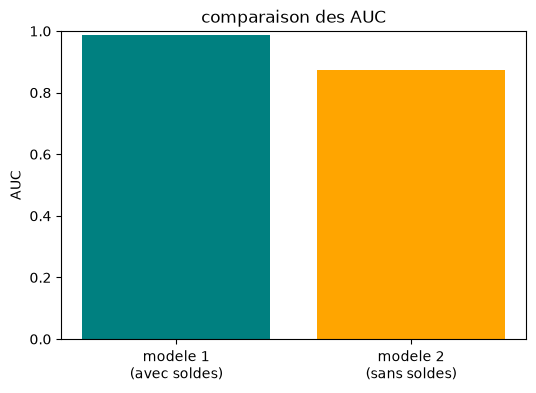

In [40]:
#  AUC
plt.figure(figsize=(6, 4))
plt.bar(["modele 1\n(avec soldes)", "modele 2\n(sans soldes)"], [auc_1, auc_2],
        color=["teal", "orange"])
plt.title("comparaison des AUC")
plt.ylabel("AUC")
plt.ylim(0, 1)
plt.show()

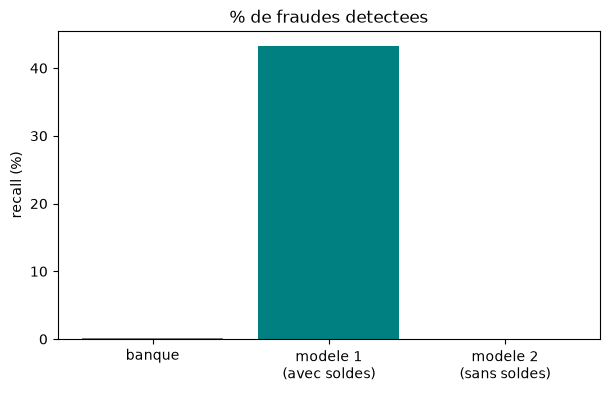

In [41]:
#recall (+ banque)
recall_banque = fraudes_oui / totalF

plt.figure(figsize=(7, 4))
plt.bar(["banque", "modele 1\n(avec soldes)", "modele 2\n(sans soldes)"],
        [100*recall_banque, 100*recall_1, 100*recall_2],
        color=["gray", "teal", "orange"])
plt.title("% de fraudes detectees")
plt.ylabel("recall (%)")
plt.show()

---
## Conclusion

1 le systeme de la banque detecte presque rien => il fallait autre chose

2 la fraude a une signature nette : TRANSFER/CASH_OUT, entre particuliers (CC), gros montants

3 le modele 1 (AUC 0.98) se base a ~70% sur les soldes = colonnes interdites par la doc
=> fuite de donnees, le score est un mirage

4 le modele 2 sans ces colonnes est plus honnete : scores plus bas mais realistes


### limites 

- dataset desequilibre (0.13% de fraudes) => l'accuracy est trompeuse, on regarde le recall
- pour ameliorer le recall : rééquilibrer les classes ou ajuster le seuil



---
# 6 : ameliorer M2

M2loupe bcp de fraudes (recall 12%)
mais son AUC est bon (0.91), seuil qui bloque?

par defaut : "fraude" seulement si proba > 0.5
MAIS DATASET DES. 0.13% de fraudes, presque jamais sur a +50%?
=> on baisse le seuil pour attraper plus de fraudes

on reutilise predictions_2, pas besoin de reentrainer(yesss)

In [42]:
from pyspark.ml.functions import vector_to_array

# on sort la proba de fraude (2eme valeur du vecteur probability)
pred_2 = predictions_2.withColumn("proba_fraude", vector_to_array("probability")[1])

# cache sinon spark recalcule tout a chaque seuil
pred_2.cache()
pred_2.count()

1272550

In [43]:
# on teste plusieurs seuils
seuils = [0.5, 0.3, 0.2, 0.1, 0.05]
recalls = []
alertes = []

for s in seuils:
    vp = pred_2.filter((pred_2.isFraud == 1) & (pred_2.proba_fraude >= s)).count()
    fn = pred_2.filter((pred_2.isFraud == 1) & (pred_2.proba_fraude < s)).count()
    fp = pred_2.filter((pred_2.isFraud == 0) & (pred_2.proba_fraude >= s)).count()
    r = 100 * vp / (vp + fn)
    recalls.append(r)
    alertes.append(fp)
    print("seuil", s, "-> recall", round(r, 1), "% | fausses alertes", fp)

seuil 0.5 -> recall 0.0 % | fausses alertes 0
seuil 0.3 -> recall 9.2 % | fausses alertes 24
seuil 0.2 -> recall 9.2 % | fausses alertes 24
seuil 0.1 -> recall 9.2 % | fausses alertes 24
seuil 0.05 -> recall 11.8 % | fausses alertes 73


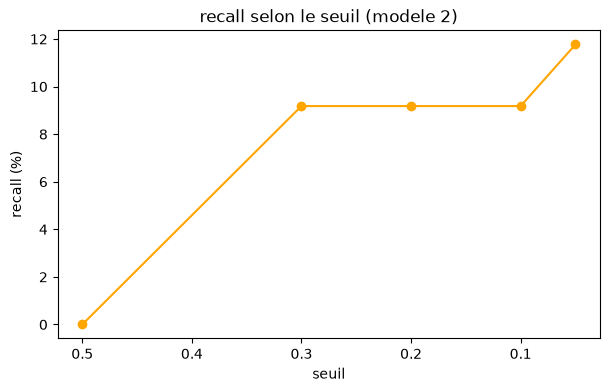

In [44]:
# recall /seuil seuil
plt.figure(figsize=(7, 4))
plt.plot(seuils, recalls, marker="o", color="orange")
plt.title("recall selon le seuil (modele 2)")
plt.xlabel("seuil")
plt.ylabel("recall (%)")
plt.gca().invert_xaxis()   # seuil qui baisse = de gauche a droite
plt.show()

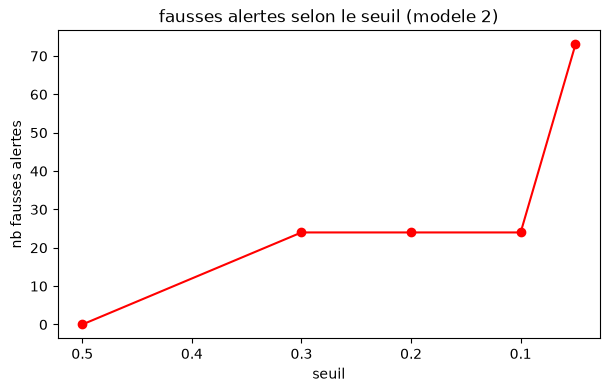

In [45]:
# fausses alertes / seuil
plt.figure(figsize=(7, 4))
plt.plot(seuils, alertes, marker="o", color="red")
plt.title("fausses alertes selon le seuil (modele 2)")
plt.xlabel("seuil")
plt.ylabel("nb fausses alertes")
plt.gca().invert_xaxis()
plt.show()

=> plus on baisse le seuil, plus on attrape de fraudes & plus on a de fausses alertes

Compromis

---
# 7 detecter les anomalies par personne

classification vs anomalies


=> pour ca il faut voir plusieurs fois la meme personne (son historique)


In [46]:
# on relit le fichier brut car nameOrig a ete supprime au nettoyage
df_brut = spark.read.csv(CHEMIN_HDFS, header=True, inferSchema=True)

nb_lignes = df_brut.count()
nb_emetteurs_uniques = df_brut.select("nameOrig").distinct().count()

print("nb transactions      :", nb_lignes)
print("nb emetteurs uniques :", nb_emetteurs_uniques)
print("transactions / personne :", round(nb_lignes / nb_emetteurs_uniques, 2))

[Stage 325:>                                                      (0 + 16) / 17]

nb transactions      : 6362620
nb emetteurs uniques : 6353307
transactions / personne : 1.0


In [47]:
# lle plus souvent
df_brut.groupBy("nameOrig").count().orderBy("count", ascending=False).show(10)

[Stage 331:=========>                                             (3 + 14) / 17]

+-----------+-----+
|   nameOrig|count|
+-----------+-----+
|C2098525306|    3|
|C1677795071|    3|
| C400299098|    3|
|C1462946854|    3|
|C1999539787|    3|
|C1065307291|    3|
|C1784010646|    3|
|C1976208114|    3|
|C2051359467|    3|
| C545315117|    3|
+-----------+-----+
only showing top 10 rows


### => notre dataset

si le nb d'emetteurs uniques est ~= au nb de transactions,
ça veut dire que chaque personne n'apparait quasiment qu'1 seule fois
=> PAS d'historique par personne
=> on NE PEUT PAS faire de detection d'anomalie par comportement avec PaySim

c'est pour ça qu'on a fait de la classification (schema general de fraude)

### colonnes intérresantes 


| colonne | a quoi ça sert |
|---|---|
| id_client (qui revient) | suivre une personne dans le temps |
| date + heure precise | voir les habitudes horaires |
| lieu / pays | reperer une transaction a l'etranger inhabituelle |
| appareil / IP | detecter une connexion depuis un nouvel appareil |
| categorie du marchand | voir si l'achat sort des habitudes |
| solde moyen habituel | comparer a la normale de la personne |




## Fin : liberer ressources

In [48]:
spark.stop()